In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

In [2]:
# Cost data
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"]         = costs.at["gas", "fuel"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]
costs.at["coal", "CO2 intensity"] = costs.at["coal", "CO2 intensity"]

In [3]:
# Cost functions
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity_values = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity_values + costs["FOM"] / 100) * costs["investment"]

In [4]:
# Load & weather data
data_solar = pd.read_csv('data/pv_optimal.csv', sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv', sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

# For this project the chosen country was Spain
country = 'ESP'

## Part g – Gas pipelines (H2 or CH4) between countries

We extend the interconnected model from part d by adding gas pipelines between Spain, France, Portugal and Morocco.

**Linear gas transport approach:**  
In PyPSA, gas pipelines are modelled using `Link` components. A `Link` moves energy from one bus to another with a given efficiency. For gas transport:
- `efficiency = 1.0` (no transport losses in the linear model)
- `p_nom` = pipeline capacity in MW (thermal)
- Gas flows are optimised simultaneously with electricity dispatch

**We test two scenarios:**
1. **CH4 pipelines** – existing natural gas infrastructure (higher capacity, already built)
2. **H2 pipelines** – future hydrogen network (lower initial capacity, zero CO2)

**Real pipeline capacities (MW thermal):**  
Spain is a major gas hub in Europe with LNG terminals and interconnections:
- Spain–France: ~7,500 MW (Larrau + Biriatou cross-border pipelines, source: ENTSOG)
- Spain–Portugal: ~4,000 MW (Campo Maior pipeline, source: REN/ENTSOG)  
- Spain–Morocco: ~5,700 MW (Maghreb–Europe Gas Pipeline, source: ENTSOG)
- France–Portugal: ~2,000 MW (assumed via Spain, indirect route)

In [ ]:
# Build the part-d electricity network first (same as part d)
# We rebuild it here so this notebook is self-contained

n = pypsa.Network()

hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')
n.set_snapshots(hours.values)

# Carriers
n.add("Carrier", "onwind",  color="dodgerblue",  co2_emissions=0.0)
n.add("Carrier", "solar",   color="gold",         co2_emissions=0.0)
n.add("Carrier", "coal",    color="indianred",     co2_emissions=costs.at["coal", "CO2 intensity"])
n.add("Carrier", "CCGT",    color="yellowgreen",   co2_emissions=costs.at["gas",  "CO2 intensity"])
n.add("Carrier", "PHS",     color="brown",         co2_emissions=0.0)
n.add("Carrier", "gas",     color="orange",        co2_emissions=costs.at["gas",  "CO2 intensity"])
n.add("Carrier", "H2",      color="lightblue",     co2_emissions=0.0)

# ELECTRICITY BUSES
n.add("Bus", "Spain electricity", carrier="AC")
n.add("Bus", "FR",                carrier="AC")
n.add("Bus", "PT",                carrier="AC")
n.add("Bus", "MA",                carrier="AC")

# GAS BUSES (CH4)
n.add("Bus", "Spain gas",   carrier="gas")
n.add("Bus", "FR gas",      carrier="gas")
n.add("Bus", "PT gas",      carrier="gas")
n.add("Bus", "MA gas",      carrier="gas")

# H2 BUSES
n.add("Bus", "Spain H2",    carrier="H2")
n.add("Bus", "FR H2",       carrier="H2")
n.add("Bus", "PT H2",       carrier="H2")
n.add("Bus", "MA H2",       carrier="H2")

print("Buses added:", n.buses.index.tolist())

Buses added: ['Spain electricity', 'FR', 'PT', 'MA', 'Spain gas', 'FR gas', 'PT gas', 'MA gas', 'Spain H2', 'FR H2', 'PT H2', 'MA H2']


In [ ]:
# ELECTRICITY LOADS

# Spain (hourly from data)
n.add("Load", "demand",
      bus="Spain electricity",
      p_set=data_el[country].values)

# Neighbours (constant average MW)
# Source: ENTSO-E statistical factsheets / IEA country data 2011
demand_avg_mw = {
    "FR": 468e6 / 8760,   # ~53,425 MW - France 2011 ~468 TWh
    "PT": 48e6  / 8760,   # ~5,479 MW  - Portugal 2011 ~48 TWh
    "MA": 28e6  / 8760,   # ~3,196 MW  - Morocco 2011 ~28 TWh
}

for country_code, p_set in demand_avg_mw.items():
    n.add("Load", f"load_{country_code}", bus=country_code, p_set=p_set)

In [ ]:
# SPAIN ELECTRICITY GENERATORS (extendable, co-optimised)

CF_wind  = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]

n.add("Generator", "CCGT",
      bus="Spain electricity",
      carrier="CCGT",
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"],
      efficiency=costs.at["CCGT", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=25300)

n.add("Generator", "coal",
      bus="Spain electricity",
      carrier="coal",
      capital_cost=costs.at["coal", "capital_cost"],
      marginal_cost=costs.at["coal", "marginal_cost"],
      efficiency=costs.at["coal", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=11700)

n.add("Generator", "onwind",
      bus="Spain electricity",
      carrier="onwind",
      p_max_pu=CF_wind.values,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      efficiency=costs.at["onwind", "efficiency"],
      p_nom_extendable=True)

n.add("Generator", "solar",
      bus="Spain electricity",
      carrier="solar",
      p_max_pu=CF_solar.values,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      efficiency=costs.at["solar", "efficiency"],
      p_nom_extendable=True)

# Pumped hydro storage
n.add("StorageUnit", "PHS",
      bus="Spain electricity",
      carrier="PHS",
      capital_cost=costs.at["PHS", "capital_cost"],
      marginal_cost=costs.at["PHS", "marginal_cost"],
      efficiency_store=costs.at["PHS", "efficiency"],
      efficiency_dispatch=costs.at["PHS", "efficiency"],
      p_nom_extendable=True,
      cyclic_state_of_charge=True)

In [ ]:
# NEIGHBOUR ELECTRICITY GENERATORS (fixed capacity)
# Source: ENTSO-E, REN (Portugal), ONEE (Morocco)

neighbour_generators = {
    "FR": [
        ("nuclear_FR", "CCGT",   63000, 1.0,  5.0),   # France nuclear (low MC)
        ("wind_FR",    "onwind",  6600,  1.0,  1.4),
    ],
    "PT": [
        ("wind_PT",    "onwind",  4378,  1.0,  1.4),
        ("gas_PT",     "CCGT",    3800,  1.0, 46.8),
    ],
    "MA": [
        ("thermal_MA", "CCGT",    4771,  1.0, 46.8),
        ("wind_MA",    "onwind",   292,  1.0,  1.4),
    ],
}

for country_code, gens in neighbour_generators.items():
    for name, carrier, p_nom, cf, mc in gens:
        n.add("Generator", name,
              bus=country_code,
              carrier=carrier,
              p_nom=p_nom,
              p_nom_extendable=False,
              p_max_pu=cf,
              marginal_cost=mc)

In [ ]:
# HVAC ELECTRICITY LINES (same as part d, fixed capacities)
# Source: ENTSO-E TYNDP / REE 2011
# FR-PT line closes the cycle: Spain -> FR -> PT -> Spain

elec_lines = [
    # (name,   bus0,              bus1,  s_nom MW, x p.u.)
    ("ES-FR",  "Spain electricity", "FR",  2800, 0.1),
    ("ES-PT",  "Spain electricity", "PT",  3000, 0.1),
    ("FR-PT",  "FR",               "PT",  2200, 0.1),  # closes the cycle
    ("ES-MA",  "Spain electricity", "MA",   900, 0.1),
]

for name, bus0, bus1, s_nom, x in elec_lines:
    n.add("Line", name,
          bus0=bus0, bus1=bus1,
          s_nom=s_nom,
          s_nom_extendable=False,
          x=x,
          v_nom=400)

print("Electricity lines:", n.lines.index.tolist())

Electricity lines: ['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA']


In [ ]:
# GAS SUPPLY (generators on gas buses)
# We model gas supply as generators on the gas buses.
# This represents LNG terminals, domestic production and imports.
# Marginal cost = gas fuel cost from the cost database.
# p_nom_extendable=True allows the model to use as much gas as needed.

gas_mc = costs.at["gas", "fuel"]  # EUR/MWh_th

for bus in ["Spain gas", "FR gas", "PT gas", "MA gas"]:
    n.add("Generator", f"gas supply {bus}",
          bus=bus,
          carrier="gas",
          p_nom_extendable=True,
          marginal_cost=gas_mc,
          capital_cost=0)

# --- H2 SUPPLY (generators on H2 buses) ---
# H2 can be produced by electrolysis or imported.
# We use a higher marginal cost than gas to reflect H2 production cost.
# Approximate H2 cost from electrolysis in 2030: ~60-80 EUR/MWh_th
# Source: IEA Global Hydrogen Review 2023

h2_mc = 70  # EUR/MWh_th

for bus in ["Spain H2", "FR H2", "PT H2", "MA H2"]:
    n.add("Generator", f"H2 supply {bus}",
          bus=bus,
          carrier="H2",
          p_nom_extendable=True,
          marginal_cost=h2_mc,
          capital_cost=0)

print("Gas and H2 supply generators added.")

Gas and H2 supply generators added.


In [ ]:
# GAS DEMAND on gas buses
# CCGT generators in each country consume gas from the gas bus.
# We model this using a Link: gas bus -> electricity bus (the CCGT).
# This replaces the simple generators from above for Spain's CCGT.
#
# For simplicity, we add gas demand as a Load on each gas bus
# representing industrial/heating gas consumption (non-electricity use).
# Source: Eurostat 2011 gas consumption data

# Gas demand for non-power sectors (constant average, MW thermal)
# Spain ~360 TWh/yr gas total, ~200 TWh non-power sector
# France ~450 TWh/yr total, ~300 TWh non-power
# Portugal ~50 TWh/yr total, ~35 TWh non-power
# Morocco ~10 TWh/yr total

gas_demand_mw = {
    "Spain gas": 200e6 / 8760,  # ~22,831 MW thermal
    "FR gas":    300e6 / 8760,  # ~34,247 MW thermal
    "PT gas":     35e6 / 8760,  # ~3,996 MW thermal
    "MA gas":     10e6 / 8760,  # ~1,142 MW thermal
}

for bus, p_set in gas_demand_mw.items():
    n.add("Load", f"gas load {bus}",
          bus=bus,
          carrier="gas",
          p_set=p_set)

# H2 demand (small, representing early H2 economy in 2030)
# Approximate 5% of gas demand converted to H2 use
h2_demand_mw = {
    "Spain H2": 10e6 / 8760,
    "FR H2":    15e6 / 8760,
    "PT H2":     2e6 / 8760,
    "MA H2":     1e6 / 8760,
}

for bus, p_set in h2_demand_mw.items():
    n.add("Load", f"H2 load {bus}",
          bus=bus,
          carrier="H2",
          p_set=p_set)

print("Gas and H2 loads added.")

Gas and H2 loads added.


In [ ]:
# CH4 GAS PIPELINES (Links between gas buses)
# Linear gas transport: efficiency=1 (no losses), p_nom = pipeline capacity
# Pipelines are bidirectional so we add two links per corridor.
#
# Real capacities from ENTSOG Transparency Platform 2011:
#   Spain-France:   7,500 MW thermal (Larrau + Biriatou)
#   Spain-Portugal: 4,000 MW thermal (Campo Maior)
#   Spain-Morocco:  5,700 MW thermal (Maghreb-Europe Gas Pipeline)
#   France-Portugal: 2,000 MW thermal (assumed)

gas_pipelines = [
    # (name,           bus0,         bus1,         p_nom MW_th)
    ("gas ES-FR",   "Spain gas",   "FR gas",    7500),
    ("gas ES-PT",   "Spain gas",   "PT gas",    4000),
    ("gas ES-MA",   "Spain gas",   "MA gas",    5700),
    ("gas FR-PT",   "FR gas",      "PT gas",    2000),
]

for name, bus0, bus1, p_nom in gas_pipelines:
    # Forward direction
    n.add("Link", name,
          bus0=bus0, bus1=bus1,
          p_nom=p_nom,
          p_nom_extendable=False,
          efficiency=1.0,       # linear gas transport, no losses
          marginal_cost=0.0,    # no transport cost (fixed pipeline)
          carrier="gas")
    # Reverse direction
    n.add("Link", name + " rev",
          bus0=bus1, bus1=bus0,
          p_nom=p_nom,
          p_nom_extendable=False,
          efficiency=1.0,
          marginal_cost=0.0,
          carrier="gas")

print("CH4 gas pipelines added:", [name for name, *_ in gas_pipelines])

CH4 gas pipelines added: ['gas ES-FR', 'gas ES-PT', 'gas ES-MA', 'gas FR-PT']


In [ ]:
# H2 PIPELINES (Links between H2 buses)
# H2 pipelines have lower capacity than gas pipelines in 2030
# because H2 infrastructure is still being built.
# We assume ~20% of gas pipeline capacity can be repurposed for H2.
#
# Source: European Hydrogen Backbone report (2022)
# Spain-France H2 corridor is a priority project in EU REPowerEU plan.

h2_pipelines = [
    # (name,           bus0,       bus1,       p_nom MW_th)
    ("H2 ES-FR",   "Spain H2",  "FR H2",   1500),  # 20% of gas capacity
    ("H2 ES-PT",   "Spain H2",  "PT H2",    800),
    ("H2 ES-MA",   "Spain H2",  "MA H2",   1140),  # Morocco green H2 export
    ("H2 FR-PT",   "FR H2",     "PT H2",    400),
]

for name, bus0, bus1, p_nom in h2_pipelines:
    n.add("Link", name,
          bus0=bus0, bus1=bus1,
          p_nom=p_nom,
          p_nom_extendable=False,
          efficiency=1.0,
          marginal_cost=0.0,
          carrier="H2")
    n.add("Link", name + " rev",
          bus0=bus1, bus1=bus0,
          p_nom=p_nom,
          p_nom_extendable=False,
          efficiency=1.0,
          marginal_cost=0.0,
          carrier="H2")

print("H2 pipelines added:", [name for name, *_ in h2_pipelines])

H2 pipelines added: ['H2 ES-FR', 'H2 ES-PT', 'H2 ES-MA', 'H2 FR-PT']


In [ ]:
# Fix ArrowStringArray dtype issue (same fix as all previous parts)

for df in [n.buses, n.loads, n.generators, n.lines, n.links, n.storage_units]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")
    df.index = pd.Index(df.index.tolist(), dtype=object)
    df.index.name = "name"

In [ ]:
# OPTIMISE THE WHOLE SYSTEM
# PyPSA co-optimises:
#   - Spain's electricity generation capacities (extendable)
#   - Electricity dispatch across all countries
#   - Gas flows through CH4 pipelines
#   - H2 flows through H2 pipelines
# DC approximation is used for electricity (linearised AC power flow)

n.optimize(solver_name="highs")

print(f"\nTotal system cost: {n.objective / 1e9:.3f} billion EUR/year")

C:\Users\User\AppData\Local\Temp\ipykernel_21932\1631517192.py:9: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 100.85it/s]
INFO:linopy.io: Writing time: 1.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 359173 primals, 840975 duals
Objective: 3.36e+10
Solver model: available
Solver message: Optim


Total system cost: 33.636 billion EUR/year


In [ ]:
# RESULTS: Optimal capacities in Spain 

spain_gens = n.generators[n.generators.bus == "Spain electricity"]
print("Optimal capacities in Spain (GW):")
print((n.generators.loc[spain_gens.index, "p_nom_opt"] / 1e3).round(2))

print("\nPHS storage capacity (GW):")
print((n.storage_units.p_nom_opt / 1e3).round(2))

Optimal capacities in Spain (GW):
name
CCGT      25.30
coal      10.95
onwind     4.08
solar     39.11
Name: p_nom_opt, dtype: float64

PHS storage capacity (GW):
name
PHS   -0.0
Name: p_nom_opt, dtype: float64


In [ ]:
# RESULTS: Electricity line flows

print("Average electricity line flows (MW):")
print(n.lines_t.p0.mean().round(1))

print("\nAverage electricity line loading (% of capacity):")
line_loading_pct = (n.lines_t.p0.abs() / n.lines.s_nom * 100)
print(line_loading_pct.mean().round(1))

Average electricity line flows (MW):
name
ES-FR   -2758.5
ES-PT    -830.1
FR-PT    1928.5
ES-MA    -496.6
dtype: float64

Average electricity line loading (% of capacity):
name
ES-FR    98.9
ES-PT    28.1
FR-PT    87.7
ES-MA    98.2
dtype: float64


In [ ]:
# RESULTS: Gas and H2 pipeline flows
# Links store flows in links_t.p0 (power leaving bus0)

# Separate gas and H2 links (excluding reverse links for clarity)
gas_link_names = [name for name, *_ in gas_pipelines]
h2_link_names  = [name for name, *_ in h2_pipelines]

print("Average CH4 pipeline flows (MW thermal):")
print(n.links_t.p0[gas_link_names].mean().round(1))

print("\nAverage H2 pipeline flows (MW thermal):")
print(n.links_t.p0[h2_link_names].mean().round(1))

# Total energy transported per network
gas_energy_TWh = n.links_t.p0[gas_link_names].abs().sum().sum() / 1e6  # MWh -> TWh
h2_energy_TWh  = n.links_t.p0[h2_link_names].abs().sum().sum()  / 1e6
elec_energy_TWh = n.lines_t.p0.abs().sum().sum() / 1e6

print(f"\nTotal energy transported per network (TWh/year):")
print(f"  Electricity (HVAC lines): {elec_energy_TWh:.2f} TWh")
print(f"  CH4 gas pipelines:        {gas_energy_TWh:.2f} TWh")
print(f"  H2 pipelines:             {h2_energy_TWh:.2f} TWh")

Average CH4 pipeline flows (MW thermal):
name
gas ES-FR    0.0
gas ES-PT    0.0
gas ES-MA    0.0
gas FR-PT    0.0
dtype: float64

Average H2 pipeline flows (MW thermal):
name
H2 ES-FR    189.8
H2 ES-PT    170.5
H2 ES-MA    114.2
H2 FR-PT      0.0
dtype: float64

Total energy transported per network (TWh/year):
  Electricity (HVAC lines): 56.31 TWh
  CH4 gas pipelines:        0.00 TWh
  H2 pipelines:             4.16 TWh


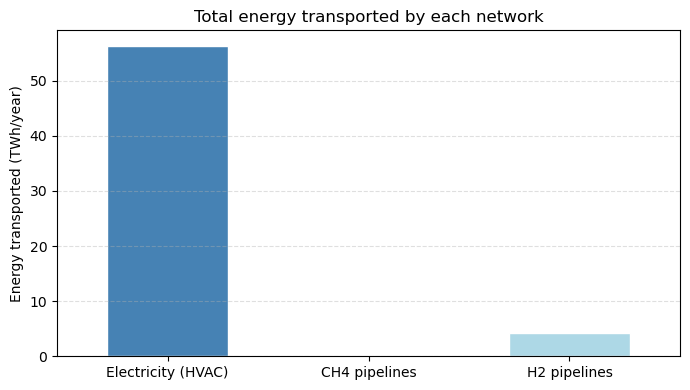


The electricity network transports more energy.


In [ ]:
# PLOT 1: Energy transported per network
# This directly answers the question: which network transports more energy?

fig, ax = plt.subplots(figsize=(7, 4))

transport_data = pd.Series({
    "Electricity (HVAC)": elec_energy_TWh,
    "CH4 pipelines":      gas_energy_TWh,
    "H2 pipelines":       h2_energy_TWh,
})

colors = ["steelblue", "orange", "lightblue"]
transport_data.plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.6)

ax.set_ylabel("Energy transported (TWh/year)")
ax.set_title("Total energy transported by each network")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nThe {'CH4 gas' if gas_energy_TWh > elec_energy_TWh else 'electricity'} network",
      "transports more energy.")

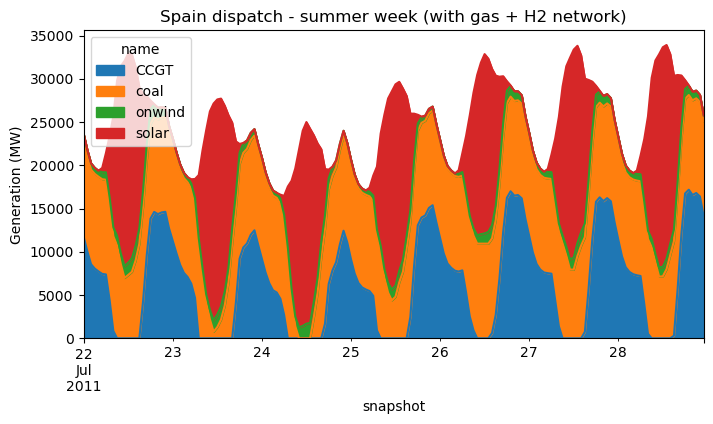

In [ ]:
# PLOT 2: Spain dispatch - summer week

spain_gen_cols = n.generators[n.generators.bus == "Spain electricity"].index

summer = n.generators_t.p.loc["2011-07-22":"2011-07-28"][spain_gen_cols]
summer.plot.area(figsize=(8, 4))
plt.ylabel("Generation (MW)")
plt.title("Spain dispatch - summer week (with gas + H2 network)")
plt.show()

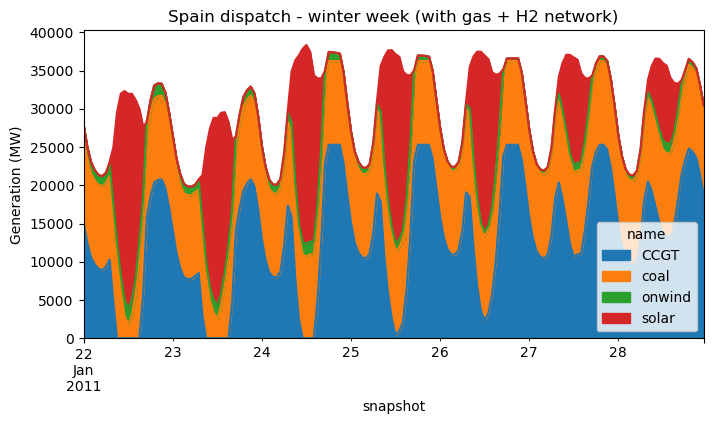

In [ ]:
# PLOT 3: Spain dispatch - winter week

winter = n.generators_t.p.loc["2011-01-22":"2011-01-28"][spain_gen_cols]
winter.plot.area(figsize=(8, 4))
plt.ylabel("Generation (MW)")
plt.title("Spain dispatch - winter week (with gas + H2 network)")
plt.show()

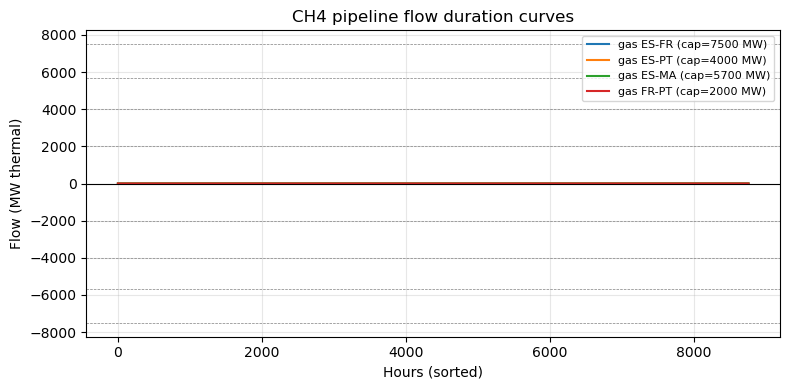

In [ ]:
# PLOT 4: CH4 pipeline flow duration curves

fig, ax = plt.subplots(figsize=(8, 4))

for line in gas_link_names:
    cap = n.links.loc[line, "p_nom"]
    sorted_flow = n.links_t.p0[line].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(sorted_flow.values, label=f"{line} (cap={cap:.0f} MW)")
    ax.axhline(cap,  color="grey", lw=0.5, ls="--")
    ax.axhline(-cap, color="grey", lw=0.5, ls="--")

ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Hours (sorted)")
ax.set_ylabel("Flow (MW thermal)")
ax.set_title("CH4 pipeline flow duration curves")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

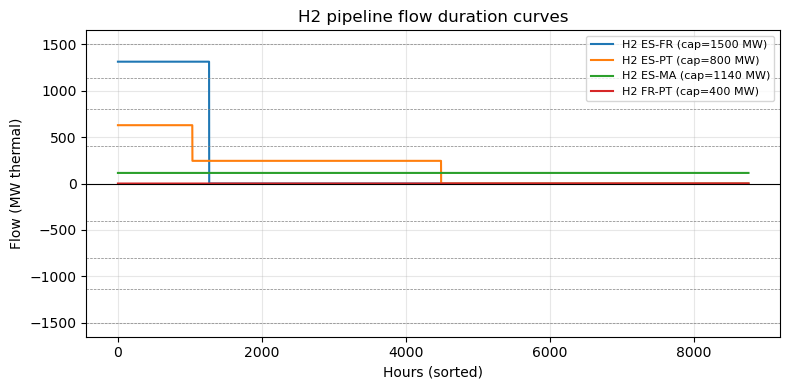

In [ ]:
# PLOT 5: H2 pipeline flow duration curves

fig, ax = plt.subplots(figsize=(8, 4))

for line in h2_link_names:
    cap = n.links.loc[line, "p_nom"]
    sorted_flow = n.links_t.p0[line].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(sorted_flow.values, label=f"{line} (cap={cap:.0f} MW)")
    ax.axhline(cap,  color="grey", lw=0.5, ls="--")
    ax.axhline(-cap, color="grey", lw=0.5, ls="--")

ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Hours (sorted)")
ax.set_ylabel("Flow (MW thermal)")
ax.set_title("H2 pipeline flow duration curves")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

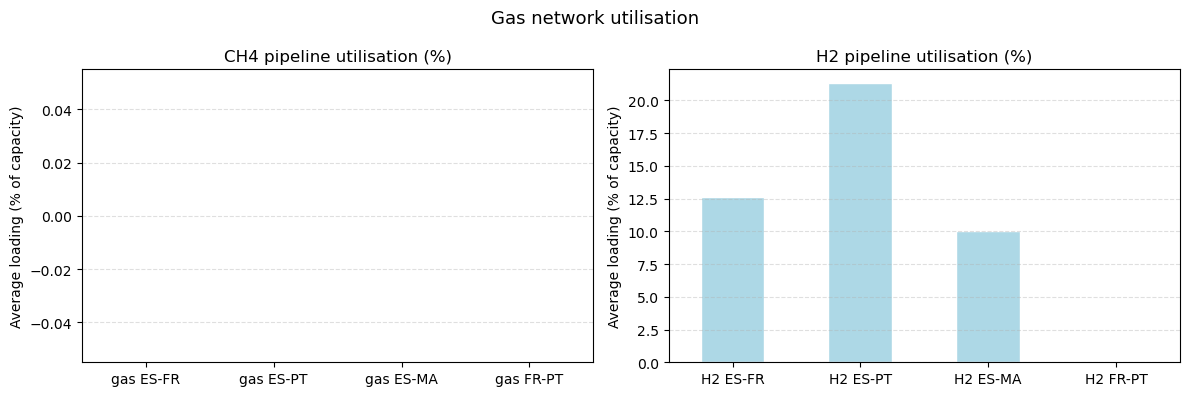

In [ ]:
# PLOT 6: Average pipeline utilisation (% of capacity)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CH4
gas_util = (n.links_t.p0[gas_link_names].abs() / n.links.loc[gas_link_names, "p_nom"] * 100).mean()
gas_util.plot(kind="bar", ax=axes[0], color="orange", edgecolor="white")
axes[0].set_title("CH4 pipeline utilisation (%)")
axes[0].set_ylabel("Average loading (% of capacity)")
axes[0].set_xlabel("")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

# H2
h2_util = (n.links_t.p0[h2_link_names].abs() / n.links.loc[h2_link_names, "p_nom"] * 100).mean()
h2_util.plot(kind="bar", ax=axes[1], color="lightblue", edgecolor="white")
axes[1].set_title("H2 pipeline utilisation (%)")
axes[1].set_ylabel("Average loading (% of capacity)")
axes[1].set_xlabel("")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.suptitle("Gas network utilisation", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# SUMMARY TABLE

summary = pd.DataFrame({
    "Network": ["Electricity (HVAC)", "CH4 pipelines", "H2 pipelines"],
    "Total energy transported (TWh/yr)": [
        round(elec_energy_TWh, 2),
        round(gas_energy_TWh, 2),
        round(h2_energy_TWh, 2),
    ],
    "Number of corridors": [len(elec_lines), len(gas_pipelines), len(h2_pipelines)],
}).set_index("Network")

print("\n=== SUMMARY: Energy Transport by Network ===")
print(summary.to_string())
print()
print("Gas supply used (average MW thermal):")
gas_supply_cols = [f"gas supply {bus}" for bus in ["Spain gas", "FR gas", "PT gas", "MA gas"]]
print(n.generators_t.p[gas_supply_cols].mean().round(1))
print()
print("H2 supply used (average MW thermal):")
h2_supply_cols = [f"H2 supply {bus}" for bus in ["Spain H2", "FR H2", "PT H2", "MA H2"]]
print(n.generators_t.p[h2_supply_cols].mean().round(1))


=== SUMMARY: Energy Transport by Network ===
                    Total energy transported (TWh/yr)  Number of corridors
Network                                                                   
Electricity (HVAC)                              56.31                    4
CH4 pipelines                                    0.00                    4
H2 pipelines                                     4.16                    4

Gas supply used (average MW thermal):
name
gas supply Spain gas    13131.1
gas supply FR gas       32246.6
gas supply PT gas        9995.4
gas supply MA gas        6841.6
dtype: float64

H2 supply used (average MW thermal):
name
H2 supply Spain H2     354.0
H2 supply FR H2       2039.2
H2 supply PT H2        803.1
H2 supply MA H2          0.0
dtype: float64
